In [1]:
#%% LOCAL PATH
import time

data_path = './data/'

#%% DATA READING

import numpy as np
from Bio import SeqIO
from sklearn.model_selection import train_test_split
on_type = {}
on_type['GRAL'] = {}

type_cell = open(data_path + '/type/uniprot_sprot_eukarya.txt','r')
on_type['EUC'] = {}

for line in type_cell:
    line = line.replace("\n","")
    line = line.split("\t")
    id_fasta = line[0]
    if id_fasta not in on_type['EUC']:
        on_type['EUC'][id_fasta] = -1
        on_type['GRAL'][id_fasta] = -1

type_cell.close()
    
type_cell = open(data_path + '/type/uniprot_sprot_archaea.txt','r')
on_type['ARC'] = {}

for line in type_cell:
    line = line.replace("\n","")
    line = line.split("\t")
    id_fasta = line[0]
    if id_fasta not in on_type['ARC']:
        on_type['ARC'][id_fasta] = -1
        on_type['GRAL'][id_fasta] = -1
    
type_cell.close()

type_cell = open(data_path + '/type/uniprot_sprot_bacteria.txt','r')
on_type['BAC'] = {}

for line in type_cell:
    line = line.replace("\n","")
    line = line.split("\t")
    id_fasta = line[0]
    if id_fasta not in on_type['BAC']:
        on_type['BAC'][id_fasta] = -1
        on_type['GRAL'][id_fasta] = -1
        
    
type_cell.close()

type_cell = open(data_path + '/type/uniprot_sprot_virus.txt','r')
on_type['VIR'] = {}

for line in type_cell:
    line = line.replace("\n","")
    line = line.split("\t")
    id_fasta = line[0]
    if id_fasta not in on_type['VIR']:
        on_type['VIR'][id_fasta] = -1
        on_type['GRAL'][id_fasta] = -1
    
    
type_cell.close()

on_type['OTR'] = {}


truetf = open(data_path + 'ListID.txt','r')
true_tf={}

for line in truetf:
    line = line.replace("\n","")
    line = line.split("\t")
    id_fasta = line[0]
    true_tf[id_fasta] = 1;
    


def read_fasta_data(fasta_file, booltf):
    
    result = []
    seq_ids = []
    fp = open(fasta_file, 'r')
    
    for seq_record in SeqIO.parse(fp, 'fasta'):
        seq = seq_record.seq
        seq_id = seq_record.id
        seqs = seq_id.split('|')
        seq_id_short = seqs[-1].replace(" ","")

        
        #if seq_id_short in on_type:
        if len(seq) <= 510:
            
            if booltf == True and seq_id in true_tf:
                result.append(str(seq))
                seq_ids.append(seq_id)
                
                
                if seq_id_short not in on_type['GRAL']:
                    on_type['OTR'][seq_id_short] = 1
                    on_type['GRAL'][seq_id_short] = 1
                else:
                    for org in on_type:
                        if seq_id_short in on_type[org]:
                            on_type[org][seq_id_short] = 1
                            on_type['GRAL'][seq_id_short] = 1
                        
                    
            else:
                
                result.append(str(seq))
                seq_ids.append(seq_id)
                
                if seq_id_short not in on_type['GRAL']:
                    on_type['OTR'][seq_id_short] = 0
                    on_type['GRAL'][seq_id_short] = 0
                else:
                    for org in on_type:
                        if seq_id_short in on_type[org]:
                            on_type[org][seq_id_short] = 0
                            on_type['GRAL'][seq_id_short] = 0
                            
    fp.close()
    return result, seq_ids

FILE_TFS = data_path + 'TFs.fasta'
FILE_NOTFS = data_path + 'NoTFs.fasta'

seq_tfs, seq_tfs_ids = read_fasta_data(FILE_TFS, True)
seq_notfs, seq_notfs_ids = read_fasta_data(FILE_NOTFS, False)

print("Secuencias de TFs: " + str(len(seq_tfs)))
print("Secuencias de No TFs: " + str(len(seq_notfs)))


print("Numero de Proteinas en Total: " + str(len(on_type['GRAL'])))


print("Numero de Proteinas en Eucariontes: " + str(len(on_type['EUC'])))
print("Numero de Proteinas en Archaea: " + str(len(on_type['ARC'])))
print("Numero de Proteinas en Bacteria: " + str(len(on_type['BAC'])))
print("Numero de Proteinas en Virus: " + str(len(on_type['VIR'])))
print("Numero de Proteinas en Otros Organismos: " + str(len(on_type['OTR'])))


Secuencias de TFs: 18137
Secuencias de No TFs: 445420
Numero de Proteinas en Total: 568002
Numero de Proteinas en Eucariontes: 195571
Numero de Proteinas en Archaea: 19697
Numero de Proteinas en Bacteria: 335618
Numero de Proteinas en Virus: 17111
Numero de Proteinas en Otros Organismos: 5


In [2]:
print(seq_notfs[0])

MRSLAILTTLLAGHAFAYPKPAPQSVNRRDWPSINEFLSELAKVMPIGDTITAACDLISDGEDAAASLFGISETENDPCGDVTVLFARGTCDPGNVGVLVGPWFFDSLQTALGSRTLGVKGVPYPASVQDFLSGSVQNGINMANQIKSVLQSCPNTKLVLGGYSQGSMVVHNAASNLDAATMSKISAVVLFGDPYYGKPVANFDAAKTLVVCHDGDNICQGGDIILLPHLTYAEDADTAAAFVVPLVS


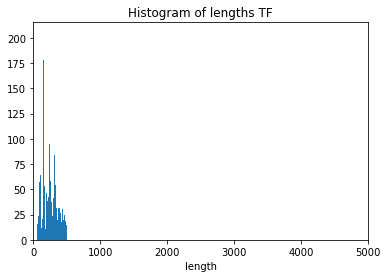

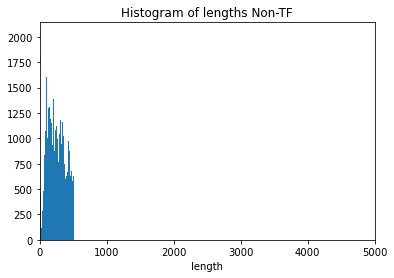

254.59325804858335 252.21199757401996
510


In [3]:
#%% PLOT LENGTH GENERATOR

import matplotlib.pyplot as plt
from statistics import mean

lengths_tfs = [len(t) for t in seq_tfs]
plt.hist(lengths_tfs , bins = len(set(lengths_tfs)))
plt.title('Histogram of lengths TF')
plt.xlabel('length')
plt.xlim(0, 5000)
plt.show()

lengths_notfs = [len(t) for t in seq_notfs]
plt.hist(lengths_notfs , bins = len(set(lengths_notfs)))
plt.title('Histogram of lengths Non-TF')
plt.xlabel('length')
plt.xlim(0, 5000)
plt.show()
print(mean(lengths_notfs), mean(lengths_tfs))
print(max(lengths_notfs))

In [4]:
#%% Conteo de aminoacidos

def amino_count(sequences):

  amino_input = set()
  amino2count = {}

  for seq in sequences:

    seq_1 = list(seq)

    for amino in seq_1:
      if amino not in amino_input:
        amino_input.add(amino)
        amino2count[amino] = 1
      else:
        amino2count[amino] += 1

  return amino2count

amino2count_tf = amino_count(seq_tfs)
amino2count_notf = amino_count(seq_notfs)

print('Aminoacids present in tf dataset: ', amino2count_tf)
print('Aminoacids present in notf dataset: ', amino2count_notf)


Aminoacids present in tf dataset:  {'M': 112925, 'G': 294046, 'R': 291997, 'K': 269035, 'I': 230227, 'Q': 207594, 'T': 237414, 'D': 245302, 'E': 341936, 'N': 186988, 'V': 270573, 'F': 148667, 'L': 422726, 'A': 354737, 'Y': 121872, 'S': 361499, 'C': 69557, 'P': 251201, 'H': 118244, 'W': 37733, 'X': 96}
Aminoacids present in notf dataset:  {'M': 2870098, 'R': 6327840, 'S': 6867658, 'L': 11080302, 'A': 9927613, 'I': 7026278, 'T': 5960177, 'G': 8406660, 'H': 2554208, 'F': 4459736, 'Y': 3312215, 'P': 5094498, 'K': 6571649, 'Q': 4171682, 'V': 8126086, 'N': 4374984, 'D': 6100329, 'W': 1234732, 'E': 7394626, 'C': 1532895, 'X': 5829, 'U': 297, 'Z': 245, 'B': 263, 'O': 29}


,Amino,Values
13,A,354737
16,C,69557
7,D,245302
8,E,341936
11,F,148667
1,G,294046
18,H,118244
4,I,230227
3,K,269035
12,L,422726


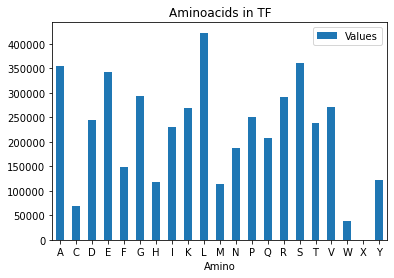

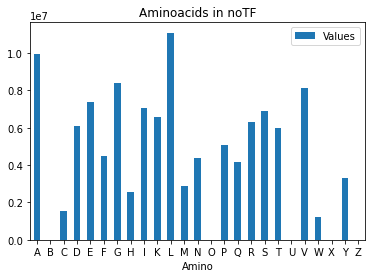

In [5]:
def histograms(amino2count_tf, amino2count_notf):
    
    import pandas as pd
    
    amino_tf = pd.DataFrame(list(amino2count_tf.items()) , columns = ['Amino', 'Values'])
    amino_tf = amino_tf.sort_values(by = ['Amino'], ascending = True)
    ax = amino_tf.plot.bar(x = 'Amino', y = 'Values', rot = 0, title = 'Aminoacids in TF')
    
    amino_notf = pd.DataFrame(list(amino2count_notf.items()) , columns = ['Amino', 'Values'])
    amino_notf = amino_notf.sort_values(by = ['Amino'])
    ax = amino_notf.plot.bar(x = 'Amino', y = 'Values', rot = 0, title = 'Aminoacids in noTF')
    
    return amino_tf

histograms(amino2count_tf, amino2count_notf)

Aminoacids present in tf dataset after cleaning:  {'M': 112639, 'G': 293220, 'R': 291181, 'K': 268300, 'I': 229610, 'Q': 206977, 'T': 236655, 'D': 244750, 'E': 340987, 'N': 186441, 'V': 269886, 'F': 148217, 'L': 421454, 'A': 353650, 'Y': 121491, 'S': 360389, 'C': 69306, 'P': 250312, 'H': 117905, 'W': 37594}
Aminoacids present in notf dataset after cleaning:  {'M': 2858521, 'R': 6306652, 'S': 6836934, 'L': 11033683, 'A': 9895408, 'I': 6996420, 'T': 5936173, 'G': 8375038, 'H': 2542689, 'F': 4437258, 'Y': 3295959, 'P': 5073081, 'K': 6546965, 'Q': 4157377, 'V': 8097425, 'N': 4355992, 'D': 6079990, 'W': 1227954, 'E': 7370698, 'C': 1525232}


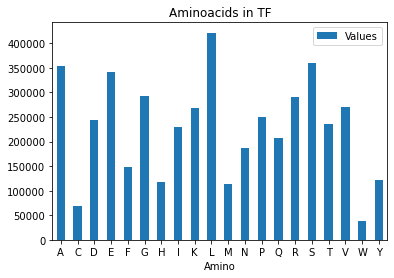

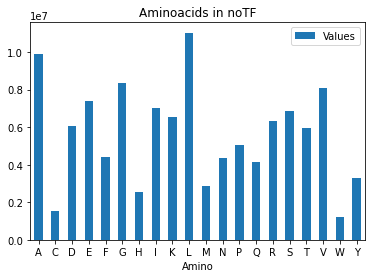

In [6]:
#%% Limpieza de secuencias. Filtro de: (B,O,U,Z)

def cleaning_sequence(sequence, ids):

    clean_seq_tfs = []
    clean_ids = []
    c = 0
    for seq in sequence:
        
        seq_1 = list(seq)
    
        if not any(amino in seq_1 for amino in ('B','O','U','Z','X')):
            clean_seq_tfs.append(seq)
            clean_ids.append(ids[c])
            
        c = c + 1
            
    return clean_seq_tfs, clean_ids

clean_seq_tfs, clean_seq_tfs_ids = cleaning_sequence(seq_tfs, seq_tfs_ids)
clean_seq_notfs, clean_seq_notfs_ids = cleaning_sequence(seq_notfs, seq_notfs_ids)

seq_tfs_ids = clean_seq_tfs_ids
seq_notfs_ids = clean_seq_notfs_ids


clean_amino2count_tf = amino_count(clean_seq_tfs)
clean_amino2count_notf = amino_count(clean_seq_notfs)

print('Aminoacids present in tf dataset after cleaning: ', clean_amino2count_tf)
print('Aminoacids present in notf dataset after cleaning: ', clean_amino2count_notf)

clean_amino_tf = histograms(clean_amino2count_tf, clean_amino2count_notf)

In [7]:
import random

def rewrite(seq):
    seqn = ""
    
    for ele in seq:
        
        if ele == 'S':
            ele = 'ser'
        
        ele = "<" + ele.lower() + ">"
        seqn = seqn + ele
    
    return seqn

clean_seq_tfs_nlp = clean_seq_tfs
for i in range(0, len(clean_seq_tfs)):
    clean_seq_tfs_nlp[i] = rewrite(clean_seq_tfs[i])

clean_seq_notfs_nlp = clean_seq_notfs
for i in range(0, len(clean_seq_notfs)):
    clean_seq_notfs_nlp[i] = rewrite(clean_seq_notfs[i])

print(clean_seq_tfs_nlp[0])
print(clean_seq_notfs_nlp[0])
print(seq_tfs_ids[0])
print(seq_notfs_ids[0])


#clean_seq_tfs_nlp = clean_seq_tfs_nlp[0:5000]
#seq_tfs_ids = seq_tfs_ids[0:5000]

clean_seq_notfs_nlp2 = []
seq_notfs_ids2 = []
indices = []

for i in range(0, len(clean_seq_tfs_nlp)*4):
    flagc = True
    while(flagc):
        index = random.randint(0,len(clean_seq_notfs_nlp)-1)
        if index not in indices:
            indices.append(index)
            clean_seq_notfs_nlp2.append(clean_seq_notfs_nlp[index])
            seq_notfs_ids2.append(seq_notfs_ids[index])
            flagc = False

clean_seq_notfs_nlp = clean_seq_notfs_nlp2
seq_notfs_ids = seq_notfs_ids2


print(clean_seq_tfs_nlp[0])
print(clean_seq_notfs_nlp[0])
print(seq_tfs_ids[0])
print(seq_notfs_ids[0])

print(len(clean_seq_notfs_nlp), len(clean_seq_tfs_nlp))

<m><g><r><k><k><i><q><i><t><r><i><m><d><e><r><n><r><q><v><t><f><t><k><r><k><f><g><l><m><k><k><a><y><e><l><ser><v><l><c><d><c><e><i><a><l><i><i><f><n><ser><t><n><k><l><f><q><y><a><ser><t><d><m><d><k><v><l><l><k><y><t><e><y><n><e><p><h><e><ser><r><t><n><ser><d><i><v><e><t><l><r><k><k><g><l><n><g><c><d><ser><p><d><p><d><a><d><d><ser><v><g><h><ser><p><e><ser><e><d><k><y><r><k><i><n><e><d><i><d><l><m><i><ser><r><q><r><l><c><a><v><p><p><p><n><f><e><m><p><v><t><i><p><v><ser><ser><h><n><ser><l><v><y><ser><n><p><v><ser><ser><l><g><n><p><n><l><l><p><l><a><h><p><ser><l><q><r><n><ser><m><ser><p><g><v><t><h><r><p><p><ser><a><g><n><t><g><g><l><m><g><g><d><l><t><ser><g><a><g><t><ser><a><g><n><g><y><g><n><p><r><n><ser><p><g><l><l><v><ser><p><g><n><l><n><k><n><i><q><a><k><ser><p><p><p><m><n><l><g><m><n><n><r><k><p><d><l><r><v><l><i><p><p><g><ser><k><n><t><m><p><ser><v><ser><e><d><v><d><l><l><l><n><q><r><i><n><n><ser><q><ser><a><q><ser><l><a><t><p><v><v><ser><v><a><t><p><t><l><p><g><q><g><m><g><g><y><p>

In [8]:
import pandas as pd

df_amino = pd.DataFrame()
df_amino['Sequence'] = None
df_amino['Class'] = None
df_amino['MultiClass'] = None

for i in range(0, len(clean_seq_tfs_nlp)):
    
    #multiclase
    
    # 0 EUC no TF
    # 1 BAC no TF
    # 2 ARC no TF
    # 3 VIR no TF
    # 4 OTR no TF
    
    # 5 EUC TF
    # 6 BAC TF
    # 7 ARC TF
    # 8 VIR TF
    # 9 OTR TF
    
    #binaria
    # 0 no TF
    # 1 TF
    
    """"""
    if seq_tfs_ids[i].split("|")[-1] in on_type['EUC']: 
        multiclase = 5
    elif seq_tfs_ids[i].split("|")[-1] in on_type['BAC']:
        multiclase = 6
    elif seq_tfs_ids[i].split("|")[-1] in on_type['ARC']:
        multiclae = 7
    elif seq_tfs_ids[i].split("|")[-1] in on_type['VIR']:
        multiclase = 8
    elif seq_tfs_ids[i].split("|")[-1] in on_type['OTR']:
        multiclase = 9
    else:
        print("error no encontrado " + seq_tfs_ids[i].split("|")[-1] )
    
    
    
    list_a = [clean_seq_tfs_nlp[i], 1, multiclase]
    df_amino.loc[seq_tfs_ids[i]] = list_a
    

print("YA LEI DATOS DE TFS:.......")

cont = 1

for i in range(0, len(clean_seq_notfs_nlp)):
    
    #multiclase
    
    # 0 EUC no TF
    # 1 BAC no TF
    # 2 ARC no TF
    # 3 VIR no TF
    # 4 OTR no TF
    
    # 5 EUC TF
    # 6 BAC TF
    # 7 ARC TF
    # 8 VIR TF
    # 9 OTR TF
    
    #binaria
    # 0 no TF
    # 1 TF
    
    #if cont <= 50000:
    if seq_notfs_ids[i].split("|")[-1] in on_type['EUC']: 
        multiclase = 0
    elif seq_notfs_ids[i].split("|")[-1] in on_type['BAC']:
        multiclase = 1
    elif seq_notfs_ids[i].split("|")[-1] in on_type['ARC']:
        multiclae = 2
    elif seq_notfs_ids[i].split("|")[-1] in on_type['VIR']:
        multiclase = 3
    elif seq_notfs_ids[i].split("|")[-1] in on_type['OTR']:
        multiclae = 4
    else:
        print("error no encontrado " + seq_notfs_ids[i].split("|")[-1] )



    list_a = [clean_seq_notfs_nlp[i], 0, multiclase]
    df_amino.loc[seq_notfs_ids[i]] = list_a

    if (cont % 50000) == 0:
        print("HE LEIDO 50,000 SECUENCIAS DE NO TFS")
    
    
    cont = cont +1
    
print("YA LEI DATOS DE NO TFS:.......")


YA LEI DATOS DE TFS:.......
HE LEIDO 50,000 SECUENCIAS DE NO TFS
YA LEI DATOS DE NO TFS:.......


In [9]:
print(df_amino[df_amino['MultiClass'] == 6])
print(df_amino.shape)

                                                                   Sequence  \
sp|A0A0H3MDW1|CHXR_CHLT2  <m><a><g><p><k><h><v><l><l><v><ser><e><h><w><d...   
sp|A0QTP2|SIGH_MYCS2      <m><t><d><v><d><r><v><e><p><e><t><p><p><e><r><...   
sp|C3W947|CTSR_GEOSE      <m><p><n><i><ser><d><i><i><e><q><y><l><k><q><v...   
sp|G3XCV0|FLEQ_PSEAE      <m><w><r><e><t><k><l><l><l><i><d><d><n><l><d><...   
sp|G3XCY4|AMRZ_PSEAE      <m><r><p><l><k><q><a><t><p><t><y><ser><ser><r>...   
...                                                                     ...   
sp|Q9XDU4|Y1954_CLOPE     <m><ser><g><h><ser><k><w><h><n><i><q><a><k><k>...   
sp|Q9YDZ1|Y778_AERPE      <m><v><q><g><l><p><g><e><f><e><d><y><l><y><r><...   
sp|Q9ZMR9|Y162_HELPJ      <m><g><r><a><f><e><y><r><r><a><a><k><e><k><r><...   
sp|Q9ZMW2|HRCA_HELPJ      <m><l><k><r><i><k><v><g><ser><d><l><n><k><k><e...   
sp|Q9ZNK0|YU82_HATHI      <m><ser><g><h><ser><k><w><h><n><i><q><a><k><k>...   

                          Class  MultiClass  
sp|A0

In [10]:
#%% IMPORTING LIBRARIES

# from transformers import GPT2LMHeadModel, GPT2Tokenizer, AutoTokenizer, AutoModelForCausalLM
# from transformers import BertTokenizer, BertModel, BertConfig, BertForSequenceClassification
from transformers import AutoTokenizer, AlbertForSequenceClassification

from torch.optim import Adam
from torch.utils.data import DataLoader, RandomSampler, TensorDataset
import tqdm
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [11]:
#%% SETTING UP DEVICE FOR TORCH

gpu_torch = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0)
print("GPU is", "available for Torch" if gpu_torch else "NOT AVAILABLE")
try:
    print('Card name: ', gpu_name)
except:
    None

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

GPU is available for Torch
Card name:  NVIDIA GeForce RTX 3090


In [12]:
df_amino.head()

,Sequence,Class,MultiClass
sp|A0A096MJY4|MEF2C_RAT,<m><g><r><k><k><i><q><i><t><r><i><m><d><e><r><...,1,5
sp|A0A0C5B5G6|MOTSC_HUMAN,<m><r><w><q><e><m><g><y><i><f><y><p><r><k><l><r>,1,5
sp|A0A0H3MDW1|CHXR_CHLT2,<m><a><g><p><k><h><v><l><l><v><ser><e><h><w><d...,1,6
sp|A0A0N7KJT8|APL25_ORYSJ,<m><w><d><l><n><d><ser><p><a><a><e><a><a><p><p...,1,5
sp|A0A178VEK7|DUO1_ARATH,<m><r><k><m><e><a><k><k><e><e><i><k><k><g><p><...,1,5


In [13]:
#%% DATA INFO
df_amino.info()
print('Null values:\n', pd.isnull(df_amino).sum())
print('Styatistic description:\n', df_amino.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 90460 entries, sp|A0A096MJY4|MEF2C_RAT to sp|Q5M7F8|F16CA_XENLA
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sequence    90460 non-null  object
 1   Class       90460 non-null  int64 
 2   MultiClass  90460 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.8+ MB
Null values:
 Sequence      0
Class         0
MultiClass    0
dtype: int64
Styatistic description:
               Class    MultiClass
count  90460.000000  90460.000000
mean       0.200000      1.725437
std        0.400002      2.046259
min        0.000000      0.000000
25%        0.000000      1.000000
50%        0.000000      1.000000
75%        0.000000      1.000000
max        1.000000      8.000000


<Figure size 432x288 with 0 Axes>

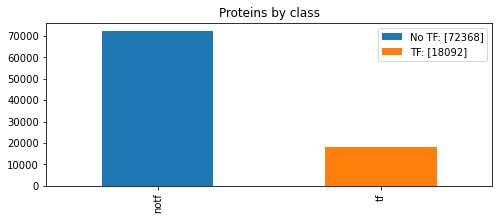

In [14]:
#%% EDA

def bar_chart_class(dataset, feature):
    
    notf = dataset[dataset['Class'] == 0][feature].value_counts()
    tf = dataset[dataset['Class'] == 1][feature].value_counts()
    df = pd.DataFrame([notf, tf])
    df.index = ['notf', 'tf']
    plt.figure()
    df.plot(kind = 'bar', stacked = True, figsize = (8,3))
    plt.legend(['No TF: {}'.format(np.array(notf)), 'TF: {}'.format(np.array(tf))])
    plt.title('Proteins by class')

bar_chart_class(df_amino, 'Class')



<Figure size 432x288 with 0 Axes>

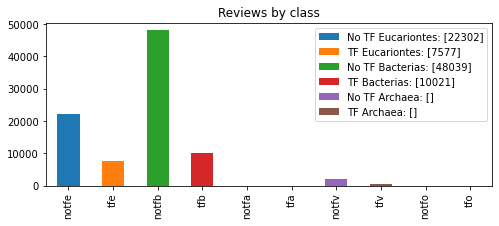

In [15]:
def bar_chart_class(dataset, feature):
    
    notfe = dataset[dataset['MultiClass'] == 0][feature].value_counts()
    tfe = dataset[dataset['MultiClass'] == 5][feature].value_counts()
    
    notfb = dataset[dataset['MultiClass'] == 1][feature].value_counts()
    tfb = dataset[dataset['MultiClass'] == 6][feature].value_counts()
    
    notfa = dataset[dataset['MultiClass'] == 2][feature].value_counts()
    tfa = dataset[dataset['MultiClass'] == 7][feature].value_counts()
    
    notfv = dataset[dataset['MultiClass'] == 3][feature].value_counts()
    tfv = dataset[dataset['MultiClass'] == 8][feature].value_counts()
    
    notfo = dataset[dataset['MultiClass'] == 4][feature].value_counts()
    tfo = dataset[dataset['MultiClass'] == 9][feature].value_counts()
    
    
    
    df = pd.DataFrame([notfe, tfe,notfb,tfb,notfa,tfa,notfv,tfv,notfo,tfo])
    df.index = ['notfe', 'tfe', 'notfb', 'tfb', 'notfa', 'tfa', 'notfv', 'tfv', 'notfo', 'tfo']
    plt.figure()
    df.plot(kind = 'bar', stacked = True, figsize = (8,3))
    plt.legend(['No TF Eucariontes: {}'.format(np.array(notfe)), 'TF Eucariontes: {}'.format(np.array(tfe)),
               'No TF Bacterias: {}'.format(np.array(notfb)), 'TF Bacterias: {}'.format(np.array(tfb)),
              'No TF Archaea: {}'.format(np.array(notfa)), 'TF Archaea: {}'.format(np.array(tfa)),
              'No TF Virus: {}'.format(np.array(notfv)), 'TF Virus: {}'.format(np.array(tfv)),
              'No TF Otros: {}'.format(np.array(notfo)), 'TF Otros: {}'.format(np.array(tfo))])
    plt.title('Reviews by class')

bar_chart_class(df_amino, 'MultiClass')


In [16]:
#%% DOWNLOADING AND SAVING MODEL/TOKENIZER FROM HUGGINGFACE

#tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
#tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-emotion")
tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")

#tokenizer.add_special_tokens({"bos_token": "<startofstring>",
#                              "eos_token": "<endofstring>"})

tokenizer.add_tokens(["<a>"]) # 1 Alanina
tokenizer.add_tokens(["<c>"]) # 2 Cisteina 
tokenizer.add_tokens(["<d>"]) # 3 Ácido Aspártico
tokenizer.add_tokens(["<e>"]) # 4 Ácido Glutámico
tokenizer.add_tokens(["<f>"]) # 5 Fenilalanina
tokenizer.add_tokens(["<g>"]) # 6 Glicina
tokenizer.add_tokens(["<h>"]) # 7 Histidina
tokenizer.add_tokens(["<i>"]) # 8 Isoleucina
tokenizer.add_tokens(["<k>"]) # 9 Lisina
tokenizer.add_tokens(["<l>"]) # 10 Leucina
tokenizer.add_tokens(["<m>"]) # 11 Metionina
tokenizer.add_tokens(["<n>"]) # 12 Aspagarina
tokenizer.add_tokens(["<p>"]) # 13 Prolina
tokenizer.add_tokens(["<q>"]) # 14 Glutamina
tokenizer.add_tokens(["<r>"]) # 15 Arginina
tokenizer.add_tokens(["<ser>"]) # 16 Serina
tokenizer.add_tokens(["<t>"]) # 17 Treonina 
tokenizer.add_tokens(["<v>"]) # 18 Valina
tokenizer.add_tokens(["<w>"]) # 19 Triptofano
tokenizer.add_tokens(["<y>"]) # 20 Tirosina

#model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2)
model = AlbertForSequenceClassification.from_pretrained('albert-base-v2')

#model = RobertaForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-emotion", num_labels = 2, ignore_mismatched_sizes=True)
model.resize_token_embeddings(len(tokenizer))


### SAVING IN LOCAL DIRECTORY
import os

output_dir = './ALBERT_base_uncase_pt_PROTEIN/'

# Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

Some weights of the model checkpoint at albert-base-v2 were not used when initializing AlbertForSequenceClassification: ['predictions.dense.bias', 'predictions.LayerNorm.bias', 'predictions.decoder.bias', 'predictions.decoder.weight', 'predictions.dense.weight', 'predictions.bias', 'predictions.LayerNorm.weight']
- This IS expected if you are initializing AlbertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing AlbertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You sho

('./ALBERT_base_uncase_pt_PROTEIN/tokenizer_config.json',
 './ALBERT_base_uncase_pt_PROTEIN/special_tokens_map.json',
 './ALBERT_base_uncase_pt_PROTEIN/tokenizer.json')

In [17]:
#%% LOADING MODEL FROM FILE

output_dir = './ALBERT_base_uncase_pt_PROTEIN/'


#tokenizer = BertTokenizer.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained(output_dir)

#tokenizer.add_special_tokens({"bos_token": "<startofstring>",
#                              "eos_token": "<endofstring>"})

tokenizer.add_tokens(["<a>"]) # 1 Alanina
tokenizer.add_tokens(["<c>"]) # 2 Cisteina 
tokenizer.add_tokens(["<d>"]) # 3 Ácido Aspártico
tokenizer.add_tokens(["<e>"]) # 4 Ácido Glutámico
tokenizer.add_tokens(["<f>"]) # 5 Fenilalanina
tokenizer.add_tokens(["<g>"]) # 6 Glicina
tokenizer.add_tokens(["<h>"]) # 7 Histidina
tokenizer.add_tokens(["<i>"]) # 8 Isoleucina
tokenizer.add_tokens(["<k>"]) # 9 Lisina
tokenizer.add_tokens(["<l>"]) # 10 Leucina
tokenizer.add_tokens(["<m>"]) # 11 Metionina
tokenizer.add_tokens(["<n>"]) # 12 Aspagarina
tokenizer.add_tokens(["<p>"]) # 13 Prolina
tokenizer.add_tokens(["<q>"]) # 14 Glutamina
tokenizer.add_tokens(["<r>"]) # 15 Arginina
tokenizer.add_tokens(["<ser>"]) # 16 Serina
tokenizer.add_tokens(["<t>"]) # 17 Treonina 
tokenizer.add_tokens(["<v>"]) # 18 Valina
tokenizer.add_tokens(["<w>"]) # 19 Triptofano
tokenizer.add_tokens(["<y>"]) # 20 Tirosina

model = AlbertForSequenceClassification.from_pretrained(output_dir,
                                                      num_labels = 2,
                                                      output_attentions = False,
                                                      output_hidden_states = False)

"""
model = BertForSequenceClassification.from_pretrained(output_dir,
                                                      num_labels = 2,
                                                      output_attentions = False,
                                                      output_hidden_states = False)
"""

model.resize_token_embeddings(len(tokenizer))

model = model.to(device)



In [18]:
print(tokenizer)
print('Length of tokenizer:', tokenizer.vocab_size)

print(f'The padding token is {tokenizer.pad_token} and the ID for the PAD token is {tokenizer.pad_token_id}.')
print(f'The unknown token is {tokenizer.unk_token} and the ID for the unkown token is {tokenizer.unk_token_id}.')
print(f'The seperator token is {tokenizer.sep_token} and the ID for the seperator token is {tokenizer.sep_token_id}.')
print(f'The sentence level classification token is {tokenizer.cls_token} and the ID for the classification token is {tokenizer.cls_token_id}.')
print(f'The mask token is {tokenizer.mask_token} and the ID for the mask token is {tokenizer.mask_token_id}.')

print(f'The start_of_sentence token is {tokenizer.bos_token} and the ID for the EOS token is {tokenizer.bos_token_id}.')
print(f'The end_of_sentence token is {tokenizer.eos_token} and the ID for the EOS token is {tokenizer.eos_token_id}.')
print(f'The amino-acid A token is: and its ID is {tokenizer("<a>").input_ids}.')
print(f'The amino-acid C token is: and its ID is {tokenizer("<c>").input_ids}.')
print(f'The amino-acid S token is: and its ID is {tokenizer("<ser>").input_ids}.')

AlbertTokenizerFast(name_or_path='./ALBERT_base_uncase_pt_PROTEIN/', vocab_size=30000, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '<unk>', 'sep_token': '[SEP]', 'pad_token': '<pad>', 'cls_token': '[CLS]', 'mask_token': AddedToken("[MASK]", rstrip=False, lstrip=True, single_word=False, normalized=False)}, clean_up_tokenization_spaces=True)
Length of tokenizer: 30000
The padding token is <pad> and the ID for the PAD token is 0.
The unknown token is <unk> and the ID for the unkown token is 1.
The seperator token is [SEP] and the ID for the seperator token is 3.
The sentence level classification token is [CLS] and the ID for the classification token is 2.
The mask token is [MASK] and the ID for the mask token is 4.
The start_of_sentence token is [CLS] and the ID for the EOS token is 2.
The end_of_sentence token is [SEP] and the ID for the EOS token is 3.
The amino-acid A token i

In [19]:
#%% FUNCTION FOR CLEANING DATA AND CONVERTING (TEXT -> PYTORCH TENSORS)
### INPUTS: Data, Tokenizer
### OUTPUTS: Encoded sentences, attention masks

class aminoacid_model:
    
    def __init__(self, data, tokenizer):
        
        sequences = list(data)
        self.X = sequences

        self.X_encoded = tokenizer(self.X, max_length = 512, 
                                   truncation = True, 
                                   padding = "max_length", 
                                   return_tensors = "pt")
        self.input_ids = self.X_encoded['input_ids']
        self.attention_mask = self.X_encoded['attention_mask']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (self.input_ids[idx], self.attention_mask[idx])

In [20]:
#%% TRAIN TEST SPLIT AND CHATDATA TENSOR

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(df_amino['Sequence'], 
                                                      df_amino['Class'], 
                                                      test_size = 0.2, 
                                                      random_state = 1, 
                                                      shuffle = True)

dataset_train = aminoacid_model(X_train, tokenizer)
dataset_valid = aminoacid_model(X_valid, tokenizer)

del df_amino

In [21]:
#%% CHATDATA EXAMPLE

ejemplo = 10

sentence = dataset_train.X[ejemplo]
sentence_encoded = dataset_train.input_ids[ejemplo]
sentence_attn = dataset_train.attention_mask[ejemplo]

print('Review text: ', sentence)
print('Review encoded: ', sentence_encoded)
print('Attention mask: ', sentence_attn)
print('Label: ', y_train[ejemplo])

sentence_decoded = tokenizer.decode(sentence_encoded)
print('sequence decoded: ', sentence_decoded)

Review text:  <m><r><v><e><i><c><i><a><k><e><k><i><t><k><m><p><n><g><a><v><d><a><l><k><e><e><l><t><r><r><i><ser><k><r><y><d><d><v><e><v><i><v><k><a><t><ser><n><d><g><l><ser><v><t><r><t><a><d><k><d><ser><a><k><t><f><v><q><e><t><l><k><d><t><w><e><ser><a><d><e><w><f><v><r>
Review encoded:  tensor([    2, 30010, 30014, 30017, 30003, 30007, 30001, 30007, 30000, 30008,
        30003, 30008, 30007, 30016, 30008, 30010, 30012, 30011, 30005, 30000,
        30017, 30002, 30000, 30009, 30008, 30003, 30003, 30009, 30016, 30014,
        30014, 30007, 30015, 30008, 30014, 30019, 30002, 30002, 30017, 30003,
        30017, 30007, 30017, 30008, 30000, 30016, 30015, 30011, 30002, 30005,
        30009, 30015, 30017, 30016, 30014, 30016, 30000, 30002, 30008, 30002,
        30015, 30000, 30008, 30016, 30004, 30017, 30013, 30003, 30016, 30009,
        30008, 30002, 30016, 30018, 30003, 30015, 30000, 30002, 30003, 30018,
        30004, 30017, 30014,     3,     0,     0,     0,     0,     0,     0,
          

In [22]:
#%% CONCATENATION OF TOKENIZATION, MASKS AND LABELS

train_set = TensorDataset(dataset_train.input_ids,
                          dataset_train.attention_mask,
                          torch.tensor(np.array(y_train))
                          )

valid_set = TensorDataset(dataset_valid.input_ids,
                          dataset_valid.attention_mask,
                          torch.tensor(np.array(y_valid))
                          )

del X_train, X_valid, y_train, y_valid

In [23]:
#%% PYTORCH DATA LOADER

batch_sizes = 32

train_dataloader = DataLoader(train_set,  # training instances
                              sampler = RandomSampler(train_set), # Pull out batches randomly
                              batch_size = batch_sizes # train with this batch size.
                              )

valid_dataloader = DataLoader(valid_set,  # training instances
                              sampler = RandomSampler(valid_set), # Pull out batches randomly
                              batch_size = batch_sizes # train with this batch size.
                              )

del train_set, valid_set

In [24]:
#%% METRICS FOR VALIDATION

def b_tp(preds, labels):
    '''Returns True Positives (TP): count of correct predictions of actual class 1'''
    return sum([preds == labels and preds == 1 for preds, labels in zip(preds, labels)])

def b_fp(preds, labels):
    '''Returns False Positives (FP): count of wrong predictions of actual class 1'''
    return sum([preds != labels and preds == 1 for preds, labels in zip(preds, labels)])

def b_tn(preds, labels):
    '''Returns True Negatives (TN): count of correct predictions of actual class 0'''
    return sum([preds == labels and preds == 0 for preds, labels in zip(preds, labels)])

def b_fn(preds, labels):
    '''Returns False Negatives (FN): count of wrong predictions of actual class 0'''
    return sum([preds != labels and preds == 0 for preds, labels in zip(preds, labels)])

def b_metrics(preds, labels):
    '''
    Returns the following metrics:
      - accuracy    = (TP + TN) / N
      - precision   = TP / (TP + FP)
      - recall      = TP / (TP + FN)
      - specificity = TN / (TN + FP)
    '''
    preds = np.argmax(preds, axis = 1).flatten()
    labels = labels.flatten()
    #print(type(preds), type(labels))
    tp = b_tp(preds, labels)
    tn = b_tn(preds, labels)
    fp = b_fp(preds, labels)
    fn = b_fn(preds, labels)
    b_accuracy = (tp + tn) / len(labels)
    b_precision = tp / (tp + fp) if (tp + fp) > 0 else 'nan'
    b_recall = tp / (tp + fn) if (tp + fn) > 0 else 'nan'
    b_specificity = tn / (tn + fp) if (tn + fp) > 0 else 'nan'
    
    return b_accuracy, b_precision, b_recall, b_specificity

In [25]:
#%% TRAINING STAGE

import time
from transformers import get_linear_schedule_with_warmup

epochs = 60
learning_rate = 1e-5
total_steps = len(train_dataloader) * epochs

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = learning_rate,
                              )

scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps = 0,
                                            num_training_steps = total_steps)

for epoch in tqdm.tqdm(range(epochs)):
    
    print('\nTraining...')
    total_train_loss = 0
    total_correct = 0
    total_count = 0
    nb_tr_steps = 0
    
    # =================================== Training ===================================
    model.train()
    
    for step, batch in enumerate(train_dataloader):
        
        # batch = tuple(t.to(device) for t in batch)
        # b_input_ids, b_masks, b_labels = batch
        
        b_input_ids = batch[0].to(device)
        b_masks = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()

        outputs = model(b_input_ids,
                        attention_mask = b_masks,
                        token_type_ids = None,
                        labels = b_labels)

        outputs.loss.backward()
        optimizer.step()

        batch_loss = outputs.loss.item()
        total_train_loss += batch_loss
        nb_tr_steps += 1

    # torch.save(model.state_dict(), "model_state.pt")
    # print(inference('hello, how are you?'))
    
    # =================================== Validation ===================================
    model.eval()
    
    val_accuracy = []
    val_precision = []
    val_recall = []
    val_specificity = []
    val_tp = []
    val_tn = []
    val_fp = []
    val_fn = []
    
    for batch in valid_dataloader:
        
        b_input_ids = batch[0].to(device)
        b_masks = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        with torch.no_grad():
            
            eval_output = model(b_input_ids,
                                attention_mask = b_masks,
                                token_type_ids = None)
            
        logits = eval_output.logits.detach().cpu().numpy()
        labels_ids = b_labels.to('cpu').numpy()
        b_accuracy, b_precision, b_recall, b_specificity= b_metrics(logits, labels_ids)
        val_accuracy.append(b_accuracy)
        
        if b_precision != 'nan': val_precision.append(b_precision)
        # Update recall only when (tp + fn) !=0; ignore nan
        if b_recall != 'nan': val_recall.append(b_recall)
        # Update specificity only when (tn + fp) !=0; ignore nan
        if b_specificity != 'nan': val_specificity.append(b_specificity)
        
        
    print('\n\t - Train loss: {:.8f}'.format(batch_loss / nb_tr_steps))
    print('\t - Validation Accuracy: {:.4f}'.format(sum(val_accuracy)/len(val_accuracy)))
    print('\t - Validation Precision: {:.4f}'.format(sum(val_precision)/len(val_precision)) if len(val_precision)>0 else '\t - Validation Precision: NaN')
    print('\t - Validation Recall: {:.4f}'.format(sum(val_recall)/len(val_recall)) if len(val_recall)>0 else '\t - Validation Recall: NaN')
    print('\t - Validation Specificity: {:.4f}\n'.format(sum(val_specificity)/len(val_specificity)) if len(val_specificity)>0 else '\t - Validation Specificity: NaN')
    

  0%|                                                                                           | 0/60 [00:00<?, ?it/s]


Training...


  2%|█▎                                                                            | 1/60 [30:44<30:13:44, 1844.48s/it]


	 - Train loss: 0.00009816
	 - Validation Accuracy: 0.9074
	 - Validation Precision: 0.7597
	 - Validation Recall: 0.7938
	 - Validation Specificity: 0.9357


Training...


  3%|██▌                                                                         | 2/60 [1:01:28<29:42:37, 1844.10s/it]

...


	 - Train loss: 0.00000003
	 - Validation Accuracy: 0.9577
	 - Validation Precision: 0.8724
	 - Validation Recall: 0.9327
	 - Validation Specificity: 0.9642


Training...


 98%|███████████████████████████████████████████████████████████████████████████▋ | 59/60 [30:13:09<30:43, 1843.79s/it]


	 - Train loss: 0.00000002
	 - Validation Accuracy: 0.9691
	 - Validation Precision: 0.9446
	 - Validation Recall: 0.8986
	 - Validation Specificity: 0.9867


Training...


100%|█████████████████████████████████████████████████████████████████████████████| 60/60 [30:43:53<00:00, 1843.90s/it]


	 - Train loss: 0.00002641
	 - Validation Accuracy: 0.9666
	 - Validation Precision: 0.9146
	 - Validation Recall: 0.9230
	 - Validation Specificity: 0.9776



In [26]:
%% SAVING MODEL AND TOKENIZER

import os

output_dir = './ALBERT_base_uncase_pt_PROTEIN_pretrained/'

#Create output directory if needed
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving model to %s" % output_dir)

model_to_save = model.module if hasattr(model, 'module') else model  # Take care of distributed/parallel training
model_to_save.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print('Model saved!')

UsageError: Cell magic `%%` not found.
